In [2]:
import pandas as pd
df=pd.read_csv("../dataset/zomato.csv")
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

np.int64(0)

In [3]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [4]:
df.shape

(51717, 17)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
missing_percentage=(df.isnull().sum() / len(df))*100
missing_percentage.sort_values(ascending=False)

dish_liked                     54.291626
rate                           15.033741
phone                           2.335789
approx_cost(for two people)     0.669026
rest_type                       0.438927
cuisines                        0.087012
location                        0.040606
url                             0.000000
address                         0.000000
votes                           0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64

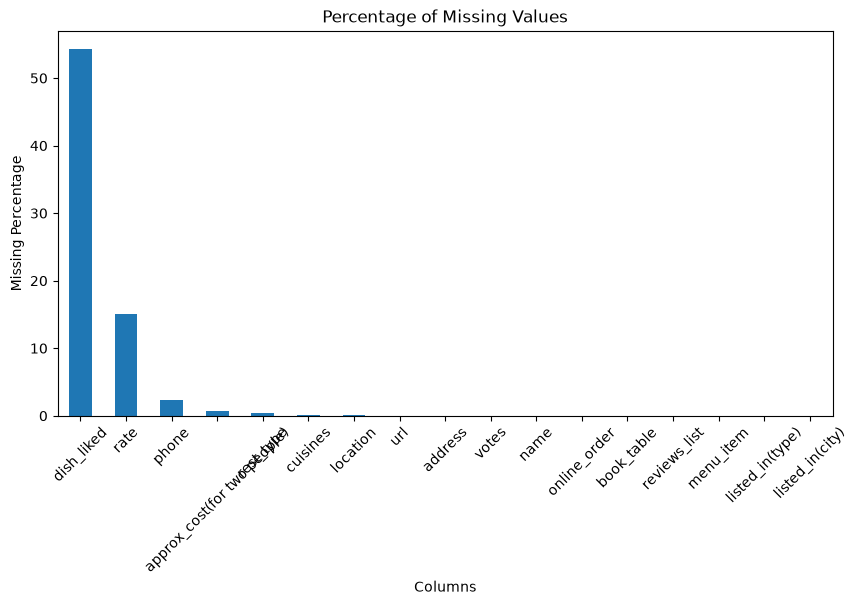

In [7]:
import matplotlib.pyplot as plt
missing_percentage.sort_values(ascending=False).plot(kind="bar",figsize=(10,5))
plt.title("Percentage of Missing Values")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=45)
plt.show()


In [8]:
df_clean=df.copy()

In [9]:
df_clean.shape

(51717, 17)

In [10]:
columns_to_drop=["url","address","phone"]
df_clean=df_clean.drop(columns=columns_to_drop)

In [11]:
df_clean.shape

(51717, 14)

In [12]:
df_clean.columns.tolist()

['name',
 'online_order',
 'book_table',
 'rate',
 'votes',
 'location',
 'rest_type',
 'dish_liked',
 'cuisines',
 'approx_cost(for two people)',
 'reviews_list',
 'menu_item',
 'listed_in(type)',
 'listed_in(city)']

In [13]:
df_clean["rate"].unique()

<StringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',    'NEW',  '2.9/5',  '3.5/5',      nan,  '2.6/5', '3.8 /5',
  '3.4/5',  '4.5/5',  '2.5/5',  '2.7/5',  '4.7/5',  '2.4/5',  '2.2/5',
  '2.3/5', '3.4 /5',      '-', '3.6 /5',  '4.8/5', '3.9 /5', '4.2 /5',
 '4.0 /5', '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
 '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5', '4.3 /5',
 '4.4 /5',  '4.9/5',  '2.1/5',  '2.0/5',  '1.8/5', '4.6 /5', '4.9 /5',
 '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5', '2.1 /5', '2.2 /5',
 '2.0 /5', '1.8 /5']
Length: 65, dtype: str

In [14]:
df_clean["rate"].isnull().sum()

np.int64(7775)

In [16]:
import numpy as np
df_clean["rate"]=df_clean["rate"].replace("NEW",np.nan)
df_clean["rate"]=df_clean["rate"].replace("-",np.nan)

In [17]:
df_clean["rate"]=df_clean["rate"].str.replace("/5","",regex=False)

In [18]:
df_clean["rate"]=pd.to_numeric(df_clean["rate"])

In [19]:
df_clean["rate"].dtype

dtype('float64')

In [20]:
df_clean["rate"].isnull().sum()

np.int64(10052)

In [21]:
df_clean["rate"].describe()

count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

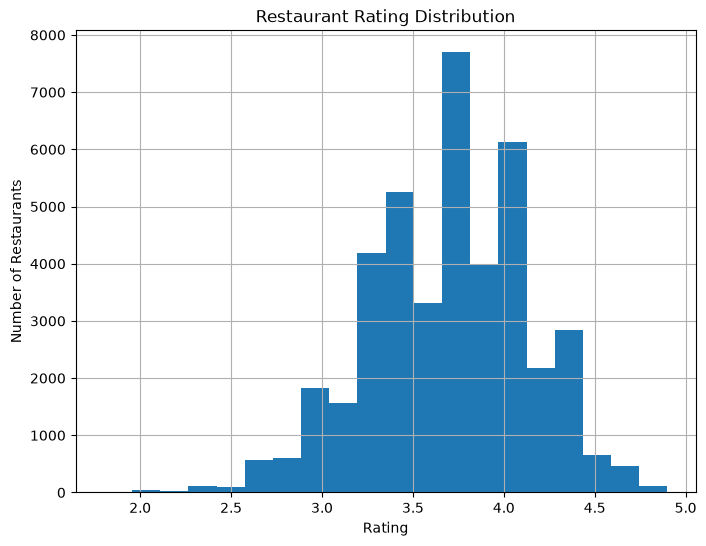

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
df_clean["rate"].hist(bins=20)
plt.title("Restaurant Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

In [24]:
df_clean[["name","rate"]].head(10)

,name,rate
0,Jalsa,4.1
1,Spice Elephant,4.1
2,San Churro Cafe,3.8
3,Addhuri Udupi Bhojana,3.7
4,Grand Village,3.8
5,Timepass Dinner,3.8
6,Rosewood International Hotel - Bar & Restaurant,3.6
7,Onesta,4.6
8,Penthouse Cafe,4.0
9,Smacznego,4.2


In [25]:
df_clean["approx_cost(for two people)"].head(10)

0    800
1    800
2    800
3    300
4    600
5    600
6    800
7    600
8    700
9    550
Name: approx_cost(for two people), dtype: str

In [26]:
df_clean["approx_cost(for two people)"].dtype

<StringDtype(storage='python', na_value=nan)>

In [27]:
df_clean["approx_cost(for two people)"].isnull().sum()

np.int64(346)

In [28]:
df_clean["approx_cost(for two people)"]=(
    df_clean["approx_cost(for two people)"]
    .str.replace(",","",regex=False)
)

In [29]:
df_clean["approx_cost(for two people)"]=pd.to_numeric(
    df_clean["approx_cost(for two people)"],
    errors="coerce"
)

In [30]:
df_clean["approx_cost(for two people)"].dtype

dtype('float64')

In [31]:
df_clean["approx_cost(for two people)"].describe()

count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64

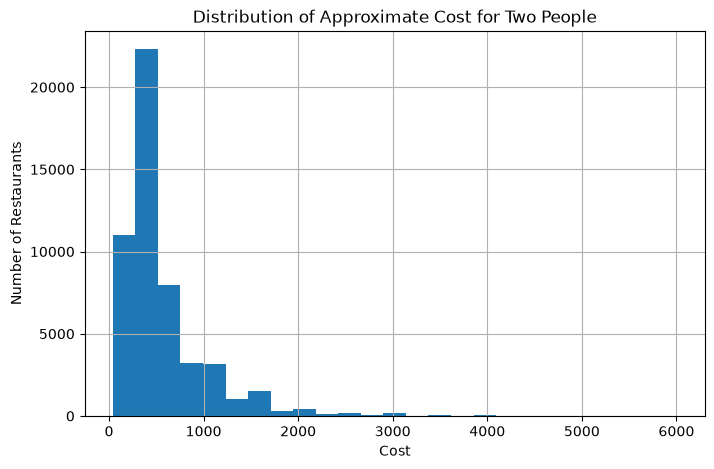

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
df_clean["approx_cost(for two people)"].hist(bins=25)
plt.title("Distribution of Approximate Cost for Two People")
plt.xlabel("Cost")
plt.ylabel("Number of Restaurants")
plt.show()

In [33]:
df_clean[["name","approx_cost(for two people)"]].head(10)

,name,approx_cost(for two people)
0,Jalsa,800.0
1,Spice Elephant,800.0
2,San Churro Cafe,800.0
3,Addhuri Udupi Bhojana,300.0
4,Grand Village,600.0
5,Timepass Dinner,600.0
6,Rosewood International Hotel - Bar & Restaurant,800.0
7,Onesta,600.0
8,Penthouse Cafe,700.0
9,Smacznego,550.0


In [34]:
df_clean.shape
df_clean.isnull().sum()
df_clean.duplicated().sum()


np.int64(63)

In [35]:
import os
os.makedirs("../dataset/cleaned",exist_ok=True)

In [36]:
df_clean.to_csv(
    "../dataset/cleaned/zomato_cleaned.csv",
    index=False
)

In [37]:
import os
os.path.exists("../dataset/cleaned/zomato_cleaned.csv")

True

In [38]:
cleaned_df=pd.read_csv("../dataset/cleaned/zomato_cleaned.csv")

In [39]:
cleaned_df.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [40]:
cleaned_df.shape

(51717, 14)

In [41]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  str    
 1   online_order                 51717 non-null  str    
 2   book_table                   51717 non-null  str    
 3   rate                         41665 non-null  float64
 4   votes                        51717 non-null  int64  
 5   location                     51696 non-null  str    
 6   rest_type                    51490 non-null  str    
 7   dish_liked                   23639 non-null  str    
 8   cuisines                     51672 non-null  str    
 9   approx_cost(for two people)  51371 non-null  float64
 10  reviews_list                 51717 non-null  str    
 11  menu_item                    51717 non-null  str    
 12  listed_in(type)              51717 non-null  str    
 13  listed_in(city)            